<a href="https://colab.research.google.com/github/RamyAkin/AI-Models/blob/main/CNNCat%26DogBiClass.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
images_path = "/content/drive/My Drive/UniWork3rdYear/Cat_Dog_CNN/Cat_Dog_Data"
testing_path = "/content/drive/My Drive/UniWork3rdYear/Cat_Dog_CNN/C_D_test"

# Define image parameters
IMG_WIDTH = 128
IMG_HEIGHT = 128
BATCH_SIZE = 32

# Load training data from the images_path
train_ds = tf.keras.utils.image_dataset_from_directory(
    images_path,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Load testing data from the testing_path
test_ds = tf.keras.utils.image_dataset_from_directory(
    testing_path,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False # No need to shuffle test set
)

print("\nTraining Dataset Info:")
print(f"Number of batches: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"Class names: {train_ds.class_names}")

print("\nTesting Dataset Info:")
print(f"Number of batches: {tf.data.experimental.cardinality(test_ds).numpy()}")
print(f"Class names: {test_ds.class_names}")

# You can iterate over these datasets to get batches of (images, labels)
# For example, to see the first batch:
for images, labels in train_ds.take(1):
    print(f"Shape of images in first batch: {images.shape}") # (batch_size, IMG_HEIGHT, IMG_WIDTH, channels)
    print(f"Shape of labels in first batch: {labels.shape}")   # (batch_size,)
    print(f"Labels in first batch: {labels.numpy()}")

Found 80 files belonging to 2 classes.
Found 6 files belonging to 2 classes.

Training Dataset Info:
Number of batches: 3
Class names: ['cat', 'dog']

Testing Dataset Info:
Number of batches: 1
Class names: ['cat', 'dog']
Shape of images in first batch: (32, 128, 128, 3)
Shape of labels in first batch: (32,)
Labels in first batch: [0 1 1 0 1 1 0 0 0 1 1 0 0 1 0 0 1 0 1 0 1 1 0 0 1 0 1 1 0 0 1 1]


In [32]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(len(train_ds.class_names), activation='softmax') # Output layer with softmax for multi-class classification
])

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,898 (12.61 MB)

 Trainable params: 3,304,898 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
# Convert train_ds to X_train and y_train NumPy arrays
X_train = []
y_train = []
for images, labels in train_ds.unbatch().as_numpy_iterator():
    X_train.append(images)
    y_train.append(labels)
X_train = np.array(X_train)
y_train = np.array(y_train)

# Convert test_ds to X_test and y_test NumPy arrays
X_test = []
y_test = []
for images, labels in test_ds.unbatch().as_numpy_iterator():
    X_test.append(images)
    y_test.append(labels)
X_test = np.array(X_test)
y_test = np.array(y_test)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Normalize pixel values (already done by Rescaling layer in the model, but good practice if using X_train/X_test directly)
# If you were to train a model directly using these NumPy arrays without the Rescaling layer,
# you would apply normalization here, e.g., X_train = X_train / 255.0 and X_test = X_test / 255.0

Shape of X_train: (80, 128, 128, 3)
Shape of y_train: (80,)
Shape of X_test: (6, 128, 128, 3)
Shape of y_test: (6,)


In [34]:
unique_labels, counts = np.unique(y_test, return_counts=True)
label_mapping = {0: 'cat', 1: 'dog'} # Assuming 0 is cat and 1 is dog from train_ds.class_names

print("Labels in y_test and their counts:")
for label, count in zip(unique_labels, counts):
    print(f"  {label_mapping.get(label, 'Unknown')}: {count}")

if len(unique_labels) < len(train_ds.class_names):
    print("\nWarning: The validation set (y_test) does not contain all classes found in the training set.")
    print("This can lead to misleading validation accuracy and prediction plots.")
    print("Consider manually ensuring a balanced class distribution in your validation data.")

Labels in y_test and their counts:
  cat: 3
  dog: 3


In [35]:
history = model.fit(X_train, y_train, epochs=15, validation_data=(X_test, y_test))

Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.3875 - loss: 343.0498 - val_accuracy: 0.3333 - val_loss: 4.5682
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.4719 - loss: 20.9655 - val_accuracy: 0.5000 - val_loss: 8.4585
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.4820 - loss: 6.0695 - val_accuracy: 0.5000 - val_loss: 2.6072
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6477 - loss: 1.4111 - val_accuracy: 0.5000 - val_loss: 2.4176
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5984 - loss: 1.2740 - val_accuracy: 0.5000 - val_loss: 0.9398
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5922 - loss: 0.8308 - val_accuracy: 0.6667 - val_loss: 0.5969
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7977 - loss: 0.4247 - val_accuracy: 0.6667 - val_loss: 0.4678
Epoch 8/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8836 - loss: 0.2984 - val_accuracy: 0.8333 - val_loss: 0.4325

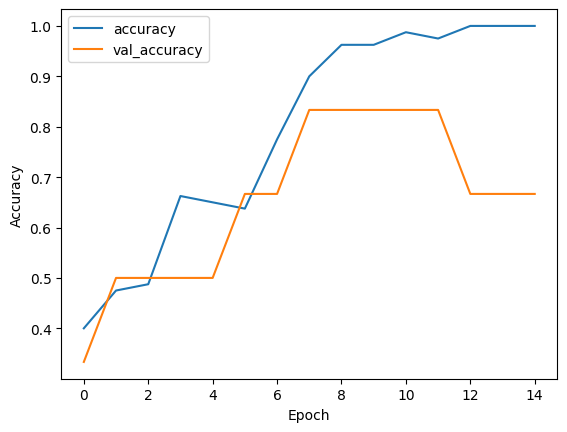

In [36]:
plt.plot(history.history['accuracy'], label= 'accuracy')
plt.plot(history.history['val_accuracy'], label= 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Displaying 6 random samples from the validation set with predictions:


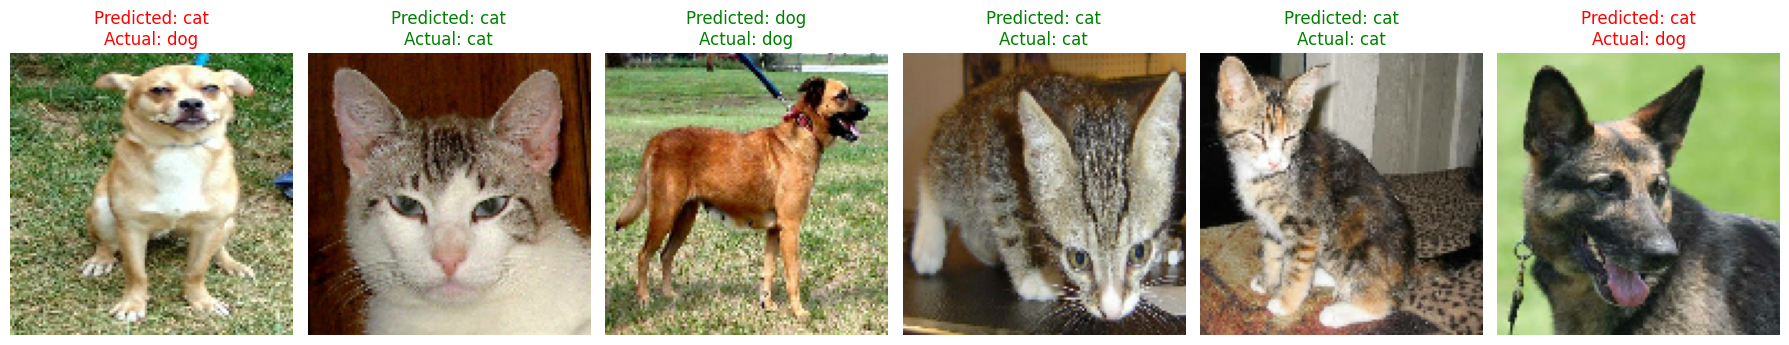

In [38]:
import random
import numpy as np
import matplotlib.pyplot as plt

# Make predictions on the collected test images
predictions = model.predict(X_test)

# Get the number of samples in the test set
num_test_samples = len(y_test)

# Determine how many samples to display
num_samples_to_display = min(6, num_test_samples)

# Get random indices to display
random_indices = random.sample(range(num_test_samples), num_samples_to_display)

print(f"Displaying {num_samples_to_display} random samples from the validation set with predictions:")

# Display the samples in a grid
plt.figure(figsize=(num_samples_to_display * 3, 4)) # Adjust figure size based on number of samples
for i, idx in enumerate(random_indices):
    plt.subplot(1, num_samples_to_display, i + 1)

    # Images are likely already float32 from 0-255, which imshow can handle
    plt.imshow(X_test[idx].astype('uint8')) # Convert to uint8 for proper display if needed

    predicted_class_index = np.argmax(predictions[idx])
    actual_class_index = y_test[idx]

    # Assuming train_ds.class_names is still accessible and valid
    predicted_class_name = train_ds.class_names[predicted_class_index]
    actual_class_name = train_ds.class_names[actual_class_index]

    color = "green" if predicted_class_index == actual_class_index else "red"
    plt.title(f"Predicted: {predicted_class_name}\nActual: {actual_class_name}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()
